In [3]:
!pip install -r {Path(os.getcwd()).parent / "requirements.txt"}
!pip install opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 6.2 MB/s  0:01:09m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 8.8 MB/s  0:00:43m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.8 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 8.9 MB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 8.1 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 8.8 MB/s  0:00:22m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 7.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 6.1 MB/s  0:00:57m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 9.1 MB/s  0:00:01eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 7.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import torch
from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/jovyan/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [11]:
def get_project_root():
    root_path = Path(os.getcwd()).parent
    return root_path

In [12]:
print(get_project_root)

<function get_project_root at 0x7de4c424bd80>


In [ ]:
root_path = Path(os.getcwd()).parent
faster_rcnn = root_path / "outputs" / "best_models" / "faster_rcnn_30.pth"


Корень проекта: /home/jovyan/work
АНАЛИЗ И СРАВНЕНИЕ МОДЕЛЕЙ ДЕТЕКЦИИ НОМЕРНЫХ ЗНАКОВ
Поиск моделей в: /home/jovyan/work
----------------------------------------------------------------------

YOLOv8n (30) не найден: /home/jovyan/work/outputs/results/runs/detect/models/yolo/yolo_n_full_training

YOLOv8s (30) не найден: /home/jovyan/work/outputs/results/runs/detect/models/yolo/yolo_s_full_training

YOLOv8m (30) не найден: /home/jovyan/work/outputs/results/runs/detect/models/yolo/yolo_m_full_training

RT-DETR не найден: /home/jovyan/work/outputs/results/runs/detect/models/rtdetr/rtdetr_full_training

Загрузка Faster R-CNN (30) из: /home/jovyan/work/models/weights/trained/faster_rcnn/faster_rcnn
  Найден results.json: /home/jovyan/work/models/weights/trained/faster_rcnn/faster_rcnn/results.json
  best_val_loss = 0.0327

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
           Модель  best_val_loss  total_epochs
Faster R-CNN (30)         0.0327            30

Таблица сохранена: /home/jovyan/work/outputs/model

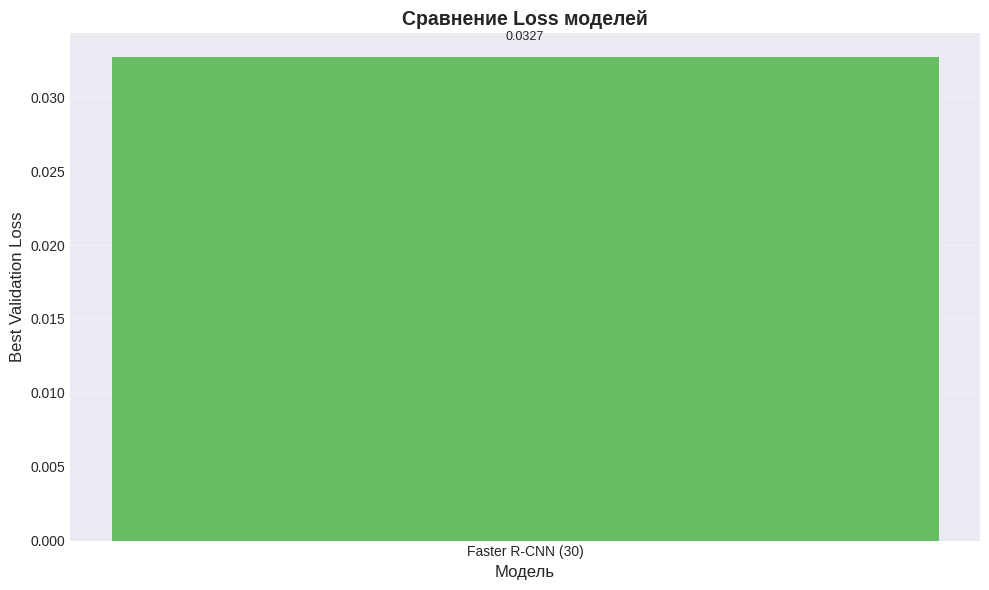


График Loss сохранен: /home/jovyan/work/outputs/model_loss_comparison.png

ИТОГОВЫЕ ВЫВОДЫ

Всего моделей загружено: 1

Найденные модели:
  ✓ Faster R-CNN (30): best_val_loss = 0.0327

🏆 Лучшая по loss: Faster R-CNN (30) (best_val_loss = 0.0327)

Результаты сохранены в:
  /home/jovyan/work/outputs/model_comparison.csv
  /home/jovyan/work/outputs/model_loss_comparison.png


In [16]:
# ============================================================================
# БЛОК 1: ИМПОРТЫ И НАСТРОЙКА
# ============================================================================

import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Определяем корень проекта
# Для Jupyter: используем текущую рабочую директорию
try:
    # Пытаемся получить путь к файлу (работает в скриптах)
    PROJECT_ROOT = Path(__file__).parent.resolve()
except NameError:
    # В Jupyter/интерактивной среде - используем текущую директорию
    PROJECT_ROOT = Path.cwd()

# Если мы в папке notebooks, поднимаемся на уровень выше
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Корень проекта: {PROJECT_ROOT}")
print("=" * 70)
print("АНАЛИЗ И СРАВНЕНИЕ МОДЕЛЕЙ ДЕТЕКЦИИ НОМЕРНЫХ ЗНАКОВ")
print("=" * 70)


# ============================================================================
# БЛОК 2: ЗАГРУЗКА РЕЗУЛЬТАТОВ МОДЕЛЕЙ
# ============================================================================

def load_model_results():
    """Загружает результаты всех моделей из правильных путей"""
    results = {}
    
    # ============================================================
    # 1. YOLO модели (30 эпох) - из results/runs/detect/models/yolo/
    # ============================================================
    yolo_base = PROJECT_ROOT / 'outputs' / 'results' / 'runs' / 'detect' / 'models' / 'yolo'
    
    yolo_models = {
        'YOLOv8n (30)': yolo_base / 'yolo_n_full_training',
        'YOLOv8s (30)': yolo_base / 'yolo_s_full_training',
        'YOLOv8m (30)': yolo_base / 'yolo_m_full_training',
    }
    
    for name, path in yolo_models.items():
        if path.exists():
            print(f"\nЗагрузка {name} из: {path}")
            data = load_yolo_metrics(path)
            if data:
                results[name] = data
        else:
            print(f"\n{name} не найден: {path}")
    
    # ============================================================
    # 2. RT-DETR (30 эпох)
    # ============================================================
    rtdetr_base = PROJECT_ROOT / 'outputs' / 'results' / 'runs' / 'detect' / 'models' / 'rtdetr'
    rtdetr_path = rtdetr_base / 'rtdetr_full_training'
    
    if rtdetr_path.exists():
        print(f"\nЗагрузка RT-DETR (30) из: {rtdetr_path}")
        data = load_yolo_metrics(rtdetr_path)
        if data:
            results['RT-DETR (30)'] = data
    else:
        print(f"\nRT-DETR не найден: {rtdetr_path}")
    
    # ============================================================
    # 3. Faster R-CNN (30 эпох)
    # ============================================================
    faster_path = PROJECT_ROOT / 'models' / 'weights' / 'trained' / 'faster_rcnn' / 'faster_rcnn'
    
    if faster_path.exists():
        print(f"\nЗагрузка Faster R-CNN (30) из: {faster_path}")
        data = load_faster_rcnn_metrics(faster_path)
        if data:
            results['Faster R-CNN (30)'] = data
    else:
        print(f"\nFaster R-CNN не найден: {faster_path}")
    
    # ============================================================
    # 4. YOLO модели (50 эпох) - если есть
    # ============================================================
    # Проверяем в runs
    for subdir in yolo_base.glob('*_50_*'):
        if subdir.is_dir() and (subdir / 'results.csv').exists():
            name = subdir.name.replace('full_training_', '').replace('_new_data', '')
            if 'n' in name.lower():
                name = 'YOLOv8n (50)'
            elif 's' in name.lower():
                name = 'YOLOv8s (50)'
            elif 'm' in name.lower():
                name = 'YOLOv8m (50)'
            else:
                name = subdir.name
            
            print(f"\nЗагрузка {name} из: {subdir}")
            data = load_yolo_metrics(subdir)
            if data:
                results[name] = data
    
    return results


def load_yolo_metrics(model_path):
    """Загружает метрики YOLO модели из results.csv"""
    csv_path = model_path / 'results.csv'
    
    if not csv_path.exists():
        print(f"  results.csv не найден в {model_path}")
        # Проверяем наличие best.pt
        best_pt = model_path / 'weights' / 'best.pt'
        if best_pt.exists():
            return {
                'has_weights': True,
                'model_path': str(best_pt),
                'info': 'Только веса (results.csv отсутствует)'
            }
        return None
    
    try:
        df = pd.read_csv(csv_path)
        
        # Проверяем наличие метрик
        if 'metrics/mAP50' in df.columns:
            best_idx = df['metrics/mAP50'].idxmax()
            return {
                'mAP50': df.loc[best_idx, 'metrics/mAP50'],
                'mAP50_95': df.loc[best_idx, 'metrics/mAP50-95'] if 'metrics/mAP50-95' in df.columns else 0,
                'precision': df.loc[best_idx, 'metrics/precision'] if 'metrics/precision' in df.columns else 0,
                'recall': df.loc[best_idx, 'metrics/recall'] if 'metrics/recall' in df.columns else 0,
                'epoch': df.loc[best_idx, 'epoch'] if 'epoch' in df.columns else 0,
                'model_path': str(csv_path),
                'has_weights': True
            }
        else:
            # Если нет mAP, пробуем другие метрики
            result = {'model_path': str(csv_path), 'has_weights': True}
            
            if 'box_loss' in df.columns:
                result['box_loss'] = df['box_loss'].min()
            if 'cls_loss' in df.columns:
                result['cls_loss'] = df['cls_loss'].min()
            if 'val_loss' in df.columns:
                result['val_loss'] = df['val_loss'].min()
            
            print(f"  Найдены альтернативные метрики: {list(result.keys())}")
            return result
            
    except Exception as e:
        print(f"  Ошибка при чтении results.csv: {e}")
        return None


def load_faster_rcnn_metrics(model_path):
    """Загружает метрики Faster R-CNN"""
    results = {}
    
    # Ищем results.json
    json_path = model_path / 'results.json'
    if json_path.exists():
        with open(json_path, 'r') as f:
            data = json.load(f)
        results = {
            'best_val_loss': data.get('best_val_loss', 0),
            'final_train_loss': data.get('final_train_loss', 0),
            'final_val_loss': data.get('final_val_loss', 0),
            'total_epochs': data.get('total_epochs', 0),
            'model_path': str(json_path),
            'has_weights': True
        }
        print(f"  Найден results.json: {json_path}")
        print(f"  best_val_loss = {results['best_val_loss']:.4f}")
        return results
    
    # Ищем history.csv
    history_path = model_path / 'history.csv'
    if history_path.exists():
        df = pd.read_csv(history_path)
        if 'val_loss' in df.columns:
            results = {
                'best_val_loss': df['val_loss'].min(),
                'final_train_loss': df['train_loss'].iloc[-1] if 'train_loss' in df.columns else 0,
                'final_val_loss': df['val_loss'].iloc[-1],
                'total_epochs': len(df),
                'model_path': str(history_path),
                'has_weights': True
            }
            print(f"  Найден history.csv: {history_path}")
            print(f"  best_val_loss = {results['best_val_loss']:.4f}")
            return results
    
    # Ищем best.pth
    best_pth = model_path / 'best.pth'
    if best_pth.exists():
        return {
            'has_weights': True,
            'model_path': str(best_pth),
            'info': 'Только веса (метрики не найдены)'
        }
    
    print(f"  Файлы метрик не найдены в {model_path}")
    return None


# ============================================================================
# БЛОК 3: СОЗДАНИЕ ТАБЛИЦЫ СРАВНЕНИЯ
# ============================================================================

def create_comparison_table(results):
    """Создает и выводит таблицу сравнения"""
    if not results:
        print("\nНет данных для сравнения")
        return None
    
    comparison_data = []
    for model_name, metrics in results.items():
        row = {'Модель': model_name}
        
        if 'mAP50' in metrics and metrics['mAP50'] > 0:
            row['mAP@0.5'] = round(metrics.get('mAP50', 0), 4)
            row['mAP@0.5:0.95'] = round(metrics.get('mAP50_95', 0), 4)
            row['Precision'] = round(metrics.get('precision', 0), 4)
            row['Recall'] = round(metrics.get('recall', 0), 4)
            row['Epoch'] = metrics.get('epoch', 0)
        elif 'best_val_loss' in metrics:
            row['best_val_loss'] = round(metrics.get('best_val_loss', 0), 4)
            row['total_epochs'] = metrics.get('total_epochs', 0)
        elif 'info' in metrics:
            row['info'] = metrics.get('info', '')
        else:
            row['info'] = 'Только веса'
        
        comparison_data.append(row)
    
    df_comparison = pd.DataFrame(comparison_data)
    
    # Сортируем по mAP если есть
    if 'mAP@0.5' in df_comparison.columns:
        df_comparison = df_comparison.sort_values('mAP@0.5', ascending=False)
    
    print("\n" + "=" * 80)
    print("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
    print("=" * 80)
    print(df_comparison.to_string(index=False))
    print("=" * 80)
    
    # Сохраняем в CSV
    output_path = OUTPUT_DIR / 'model_comparison.csv'
    df_comparison.to_csv(output_path, index=False)
    print(f"\nТаблица сохранена: {output_path}")
    
    return df_comparison


# ============================================================================
# БЛОК 4: ВИЗУАЛИЗАЦИЯ
# ============================================================================

def plot_comparison(df_comparison):
    """Строит графики сравнения"""
    if df_comparison is None or len(df_comparison) == 0:
        print("Нет данных для визуализации")
        return
    
    # Проверяем, какие метрики доступны
    has_mAP = 'mAP@0.5' in df_comparison.columns
    has_precision = 'Precision' in df_comparison.columns
    has_loss = 'best_val_loss' in df_comparison.columns
    
    if has_mAP:
        # График для mAP
        fig, ax = plt.subplots(figsize=(12, 6))
        models = df_comparison['Модель'].values
        mAP50 = df_comparison['mAP@0.5'].values
        mAP50_95 = df_comparison['mAP@0.5:0.95'].values if 'mAP@0.5:0.95' in df_comparison.columns else []
        
        x = np.arange(len(models))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, mAP50, width, label='mAP@0.5', color='royalblue')
        if len(mAP50_95) > 0 and sum(mAP50_95) > 0:
            bars2 = ax.bar(x + width/2, mAP50_95, width, label='mAP@0.5:0.95', color='coral')
        
        ax.set_xlabel('Модель', fontsize=12)
        ax.set_ylabel('mAP', fontsize=12)
        ax.set_title('Сравнение mAP моделей', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        
        # Добавляем значения на столбцы
        for bar in bars1:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'model_mAP_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nГрафик mAP сохранен: {OUTPUT_DIR / 'model_mAP_comparison.png'}")
    
    if has_precision:
        # График для Precision/Recall
        fig, ax = plt.subplots(figsize=(12, 6))
        models = df_comparison['Модель'].values
        precision = df_comparison['Precision'].values
        recall = df_comparison['Recall'].values
        
        x = np.arange(len(models))
        width = 0.35
        
        ax.bar(x - width/2, precision, width, label='Precision', color='forestgreen')
        ax.bar(x + width/2, recall, width, label='Recall', color='goldenrod')
        
        ax.set_xlabel('Модель', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('Сравнение Precision и Recall', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'model_precision_recall_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nГрафик Precision/Recall сохранен: {OUTPUT_DIR / 'model_precision_recall_comparison.png'}")
    
    if has_loss:
        # График для loss
        fig, ax = plt.subplots(figsize=(10, 6))
        models = df_comparison['Модель'].values
        losses = df_comparison['best_val_loss'].values
        
        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models)))
        bars = ax.bar(models, losses, color=colors)
        ax.set_xlabel('Модель', fontsize=12)
        ax.set_ylabel('Best Validation Loss', fontsize=12)
        ax.set_title('Сравнение Loss моделей', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Добавляем значения на столбцы
        for bar, loss in zip(bars, losses):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{loss:.4f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'model_loss_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nГрафик Loss сохранен: {OUTPUT_DIR / 'model_loss_comparison.png'}")


# ============================================================================
# БЛОК 5: ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================================

def print_summary(results):
    """Выводит итоговые результаты"""
    print("\n" + "=" * 70)
    print("ИТОГОВЫЕ ВЫВОДЫ")
    print("=" * 70)
    
    if not results:
        print("Модели не найдены. Проверьте пути.")
        print(f"Текущая директория: {PROJECT_ROOT}")
        print(f"Проверьте папки:")
        print(f"  - {PROJECT_ROOT / 'outputs' / 'results' / 'runs' / 'detect' / 'models' / 'yolo'}")
        print(f"  - {PROJECT_ROOT / 'outputs' / 'results' / 'runs' / 'detect' / 'models' / 'rtdetr'}")
        print(f"  - {PROJECT_ROOT / 'models' / 'weights' / 'trained' / 'faster_rcnn'}")
        return
    
    print(f"\nВсего моделей загружено: {len(results)}")
    print("\nНайденные модели:")
    
    for name, metrics in results.items():
        if 'mAP50' in metrics and metrics['mAP50'] > 0:
            print(f"  ✓ {name}: mAP@0.5 = {metrics['mAP50']:.4f}, mAP@0.5:0.95 = {metrics.get('mAP50_95', 0):.4f}")
        elif 'best_val_loss' in metrics:
            print(f"  ✓ {name}: best_val_loss = {metrics['best_val_loss']:.4f}")
        elif 'info' in metrics:
            print(f"  • {name}: {metrics['info']}")
        else:
            print(f"  • {name}: только веса модели")
    
    # Находим лучшую модель по mAP
    best_mAP = None
    best_mAP_name = None
    best_loss = None
    best_loss_name = None
    
    for name, metrics in results.items():
        if 'mAP50' in metrics and metrics['mAP50'] > 0:
            if best_mAP is None or metrics['mAP50'] > best_mAP:
                best_mAP = metrics['mAP50']
                best_mAP_name = name
        if 'best_val_loss' in metrics:
            if best_loss is None or metrics['best_val_loss'] < best_loss:
                best_loss = metrics['best_val_loss']
                best_loss_name = name
    
    print("\n" + "=" * 70)
    if best_mAP_name:
        print(f"🏆 Лучшая по mAP@0.5: {best_mAP_name} ({best_mAP:.4f})")
    if best_loss_name:
        print(f"🏆 Лучшая по loss: {best_loss_name} (best_val_loss = {best_loss:.4f})")
    print("=" * 70)
    
    print("\nРезультаты сохранены в:")
    print(f"  {OUTPUT_DIR / 'model_comparison.csv'}")
    if (OUTPUT_DIR / 'model_mAP_comparison.png').exists():
        print(f"  {OUTPUT_DIR / 'model_mAP_comparison.png'}")
    if (OUTPUT_DIR / 'model_precision_recall_comparison.png').exists():
        print(f"  {OUTPUT_DIR / 'model_precision_recall_comparison.png'}")
    if (OUTPUT_DIR / 'model_loss_comparison.png').exists():
        print(f"  {OUTPUT_DIR / 'model_loss_comparison.png'}")
    print("=" * 70)


# ============================================================================
# БЛОК 6: ОСНОВНОЙ КОД
# ============================================================================

def main():
    """Основная функция"""
    
    print(f"Поиск моделей в: {PROJECT_ROOT}")
    print("-" * 70)
    
    # Загружаем результаты
    results = load_model_results()
    
    # Создаем таблицу сравнения
    df_comparison = create_comparison_table(results)
    
    # Строим графики
    if df_comparison is not None:
        plot_comparison(df_comparison)
    
    # Выводим итоги
    print_summary(results)

if __name__ == "__main__":
    main()